# Whole-session locomotor spectral analysis

This notebook runs the first-stage, whole-session analysis across all `behavior_v1.h5` files represented in `cc_data`.

It expects the batch module at:

```text
src/proc/whole_session_spectral_batch.py
```

The workflow produces:

- one row per animal-session,
- long-form whole-session PSDs,
- quality-control and error tables,
- longitudinal plots,
- phase summaries,
- exploratory mixed-effects screening.

The main goal is to identify which spectral outcomes should be carried forward into within-session, trial-level, and event-aligned analyses.


In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Locate the repository and import local modules

In [4]:
def find_repo_root(start_path=None):
    start_path = Path.cwd() if start_path is None else Path(start_path)
    start_path = start_path.resolve()

    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src").is_dir():
            return candidate

    raise RuntimeError(
        "Could not find the repository root containing the src directory."
    )


repo_root = find_repo_root()

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Repository root:", repo_root)


Repository root: /home/nmldata2/ccaw/Python


In [5]:
import src.utils.config as config
import src.utils.data_io as dio

from src.proc.whole_session_spectral_batch import (
    WholeSessionSpectralConfig,
    build_whole_session_spectral_tables,
    save_whole_session_spectral_tables,
)

print("RAW_BASE:", config.RAW_BASE)
print("PROC_BASE:", config.PROC_BASE)


/home/nmldata2/ccaw/Python
RAW_BASE: /mnt/data/Classical_Conditioning
PROC_BASE: /mnt/pdata/Classical_Conditioning


## 2. Build `cc_data`

In [6]:
data_root = config.RAW_BASE
pdata_root = config.PROC_BASE

cc_data = dio.build_classical_conditioning_dict(data_root)

print("Top-level animal entries:", len(cc_data))


Top-level animal entries: 5


## 3. Configure the analysis

Primary signal-processing path:

```text
native dist_net_cm
→ 20-ms Savitzky–Golay derivative
→ zero-phase 20-Hz low-pass
→ 100-Hz analysis series
→ 10-s Welch PSD with 50% overlap
```


In [7]:
spectral_cfg = WholeSessionSpectralConfig(
    analysis_hz=100.0,

    derivative_window_ms=20.0,
    derivative_polyorder=3,

    speed_lowpass_hz=20.0,
    filter_order=4,

    welch_window_s=10.0,
    welch_overlap_fraction=0.50,

    spectral_fmin_hz=0.10,
    spectral_fmax_hz=20.0,

    behavior_window_s=2.0,
    movement_threshold_cms=0.20,

    spectral_slope_fmin_hz=1.0,
    spectral_slope_fmax_hz=10.0,
)

spectral_cfg


WholeSessionSpectralConfig(analysis_hz=100.0, derivative_window_ms=20.0, derivative_polyorder=3, speed_lowpass_hz=20.0, filter_order=4, welch_window_s=10.0, welch_overlap_fraction=0.5, spectral_fmin_hz=0.1, spectral_fmax_hz=20.0, behavior_window_s=2.0, movement_threshold_cms=0.2, spectral_slope_fmin_hz=1.0, spectral_slope_fmax_hz=10.0)

## 4. Select sessions

Leave these as `None` to process every session represented in `cc_data`.

Examples:

```python
animals_to_process = ["NML_06"]
phases_to_process = ["repeated_exposure", "air_training"]
```


In [8]:
animals_to_process = None
phases_to_process = None


## 5. Run the whole-session batch analysis

In [9]:
(
    whole_session_df,
    whole_session_psd_df,
    whole_session_errors_df,
) = build_whole_session_spectral_tables(
    cc_data=cc_data,
    config=spectral_cfg,

    # Leave as None when pdata_io already uses config.PROC_BASE.
    root=None,

    animals=animals_to_process,
    phases=phases_to_process,
    verbose=True,
)

print()
print("Sessions processed:", len(whole_session_df))
print("PSD rows:", len(whole_session_psd_df))
print("Sessions skipped:", len(whole_session_errors_df))


[1/272] NML_04 | 2025_12_27 | repeated_exposure
[2/272] NML_04 | 2025_12_28 | repeated_exposure
[3/272] NML_04 | 2025_12_29 | repeated_exposure
[4/272] NML_04 | 2025_12_30 | repeated_exposure
[5/272] NML_04 | 2025_12_31 | repeated_exposure
[6/272] NML_04 | 2026_01_01 | repeated_exposure
[7/272] NML_04 | 2026_01_02 | repeated_exposure
[8/272] NML_04 | 2026_01_03 | repeated_exposure
[9/272] NML_04 | 2026_01_04 | repeated_exposure
[10/272] NML_04 | 2026_01_05 | repeated_exposure
[11/272] NML_04 | 2026_01_06 | repeated_exposure
[12/272] NML_04 | 2026_01_07 | repeated_exposure
[13/272] NML_04 | 2026_01_08 | repeated_exposure
[14/272] NML_04 | 2026_01_09 | repeated_exposure
[15/272] NML_04 | 2026_01_10 | repeated_exposure
[16/272] NML_04 | 2026_01_11 | repeated_exposure
[17/272] NML_04 | 2026_01_12 | air_training
[18/272] NML_04 | 2026_01_13 | air_training
[19/272] NML_04 | 2026_01_14 | air_training
[20/272] NML_04 | 2026_01_15 | air_training
[21/272] NML_04 | 2026_01_16 | air_training
[22/2

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[188/272] NML_07 | 2026_03_06 | air_training
[189/272] NML_07 | 2026_03_07 | air_training
[190/272] NML_07 | 2026_03_08 | air_training
[191/272] NML_07 | 2026_03_09 | air_training
[192/272] NML_07 | 2026_03_10 | air_training
[193/272] NML_07 | 2026_03_11 | air_training
[194/272] NML_07 | 2026_03_12 | tone_air_training
[195/272] NML_07 | 2026_03_13 | tone_air_training
[196/272] NML_07 | 2026_03_14 | tone_air_training
[197/272] NML_07 | 2026_03_15 | tone_air_training
[198/272] NML_07 | 2026_03_16 | tone_air_training
[199/272] NML_07 | 2026_03_17 | tone_air_training
[200/272] NML_07 | 2026_03_18 | tone_air_training
[201/272] NML_07 | 2026_03_19 | tone_air_training
[202/272] NML_07 | 2026_03_20 | tone_air_training
[203/272] NML_07 | 2026_03_21 | tone_air_training
[204/272] NML_07 | 2026_03_23 | unknown
  SKIPPED: FileNotFoundError: No behavior_v1.h5 found for NML_07, 2026_03_23.
[205/272] NML_07 | 2026_03_24 | unknown
  SKIPPED: FileNotFoundError: No behavior_v1.h5 found for NML_07, 2026_0

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


[220/272] NML_08 | 2026_02_07 | repeated_exposure
[221/272] NML_08 | 2026_02_08 | repeated_exposure
[222/272] NML_08 | 2026_02_09 | repeated_exposure
[223/272] NML_08 | 2026_02_10 | repeated_exposure
[224/272] NML_08 | 2026_02_11 | repeated_exposure
[225/272] NML_08 | 2026_02_12 | repeated_exposure
[226/272] NML_08 | 2026_02_13 | repeated_exposure
[227/272] NML_08 | 2026_02_14 | repeated_exposure
[228/272] NML_08 | 2026_02_15 | repeated_exposure
[229/272] NML_08 | 2026_02_16 | repeated_exposure
[230/272] NML_08 | 2026_02_17 | repeated_exposure
[231/272] NML_08 | 2026_02_18 | repeated_exposure
[232/272] NML_08 | 2026_02_19 | repeated_exposure
[233/272] NML_08 | 2026_02_20 | repeated_exposure
[234/272] NML_08 | 2026_02_21 | air_training
[235/272] NML_08 | 2026_02_22 | air_training
[236/272] NML_08 | 2026_02_23 | air_training
  SKIPPED: FileNotFoundError: No behavior_v1.h5 found for NML_08, 2026_02_23.
[237/272] NML_08 | 2026_02_25 | air_training
[238/272] NML_08 | 2026_02_26 | air_traini

/home/nmldata2/ccaw/Python/src/proc/whole_session_spectral_batch.py:874: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  whole_session_df["_date_sort"] = pd.to_datetime(


## 6. Save the output tables

In [10]:
whole_session_output_dir = (
    Path(config.PROC_BASE)
    / "spectral_analysis"
    / "whole_session"
)

saved_paths = save_whole_session_spectral_tables(
    whole_session_df=whole_session_df,
    whole_session_psd_df=whole_session_psd_df,
    errors_df=whole_session_errors_df,
    output_dir=whole_session_output_dir,
)

for name, path in saved_paths.items():
    print(f"{name}: {path}")


whole_session: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session/whole_session_spectral_features.csv
psd_long: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session/whole_session_psd_long.csv
errors: /mnt/pdata/Classical_Conditioning/spectral_analysis/whole_session/whole_session_spectral_errors.csv


## 7. Processing coverage and errors

Confirm that the expected animals, phases, and dates were included before interpreting any results.


In [11]:
if whole_session_df.empty:
    raise RuntimeError(
        "No sessions were processed. Inspect whole_session_errors_df."
    )

coverage = (
    whole_session_df
    .groupby(["animal", "phase"], dropna=False)
    .agg(
        sessions=("date", "count"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

display(coverage)

if whole_session_errors_df.empty:
    print("No processing errors.")
else:
    display(whole_session_errors_df)


,animal,phase,sessions,first_date,last_date
0,NML_04,air_training,15,2026_01_12,2026_01_27
1,NML_04,repeated_exposure,16,2025_12_27,2026_01_11
2,NML_04,tone_air_training,10,2026_01_28,2026_02_06
3,NML_05,air_training,15,2026_01_12,2026_01_27
4,NML_05,repeated_exposure,16,2025_12_27,2026_01_11
5,NML_05,tone_air_training,10,2026_01_28,2026_02_06
6,NML_06,air_training,15,2026_01_12,2026_01_27
7,NML_06,repeated_exposure,16,2025_12_27,2026_01_11
8,NML_06,tone_air_training,10,2026_01_28,2026_02_06
9,NML_07,air_training,17,2026_02_21,2026_03_11


,animal,date,phase,error_type,error_message
0,NML_04,2026_02_07,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_07."
1,NML_04,2026_02_08,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_08."
2,NML_04,2026_02_09,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_09."
3,NML_04,2026_02_10,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_10."
4,NML_04,2026_02_11,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_11."
5,NML_04,2026_02_12,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_12."
6,NML_04,2026_02_13,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_13."
7,NML_04,2026_02_14,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_14."
8,NML_04,2026_02_15,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_15."
9,NML_04,2026_02_16,unknown,FileNotFoundError,"No behavior_v1.h5 found for NML_04, 2026_02_16."


## 8. Main whole-session feature table

In [12]:
overview_columns = [
    "animal",
    "date",
    "phase",
    "animal_session",
    "phase_session",
    "phase_n_sessions",
    "phase_progress_0_1",

    "duration_min",
    "mean_abs_speed_cms",
    "fraction_moving_2s_windows",
    "net_displacement_cm",
    "path_distance_from_native_speed_cm",

    "signed_total_power_0p1_20",
    "signed_relative_power_slow_0p5_2",
    "signed_relative_power_intermediate_2_5",
    "signed_dominant_frequency_hz",
    "signed_spectral_centroid_hz",
    "signed_spectral_entropy",
    "signed_spectral_slope_1_10",

    "path_relative_power_slow_0p5_2",
    "path_relative_power_intermediate_2_5",
    "path_spectral_centroid_hz",
    "path_spectral_entropy",

    "near_immobile_2s_mean_abs_speed_p99_cms",
    "native_vs_stored_speed_r",
]

available_overview_columns = [
    column
    for column in overview_columns
    if column in whole_session_df.columns
]

display(
    whole_session_df[
        available_overview_columns
    ].sort_values(["animal", "animal_session"])
)


,animal,date,phase,animal_session,phase_session,phase_n_sessions,phase_progress_0_1,duration_min,mean_abs_speed_cms,fraction_moving_2s_windows,...,signed_dominant_frequency_hz,signed_spectral_centroid_hz,signed_spectral_entropy,signed_spectral_slope_1_10,path_relative_power_slow_0p5_2,path_relative_power_intermediate_2_5,path_spectral_centroid_hz,path_spectral_entropy,near_immobile_2s_mean_abs_speed_p99_cms,native_vs_stored_speed_r
0,NML_04,2025_12_27,repeated_exposure,1,1,16,0.000000,21.846667,0.821618,0.596947,...,1.4,1.341580,0.620208,-3.535073,0.387423,0.238038,1.503036,0.648820,0.121268,0.992502
1,NML_04,2025_12_28,repeated_exposure,2,2,16,0.066667,24.556667,0.629095,0.652174,...,1.1,1.497001,0.628652,-3.284825,0.318190,0.253514,1.593164,0.648935,0.075412,0.987586
2,NML_04,2025_12_29,repeated_exposure,3,3,16,0.133333,20.908333,0.739486,0.633174,...,0.1,1.382578,0.645609,-3.245448,0.458074,0.165994,1.427862,0.644550,0.054334,0.989799
3,NML_04,2025_12_30,repeated_exposure,4,4,16,0.200000,27.070000,0.932188,0.482759,...,0.1,1.197298,0.618128,-3.674418,0.486570,0.144557,1.209013,0.612522,0.051876,0.995896
4,NML_04,2025_12_31,repeated_exposure,5,5,16,0.266667,22.110000,0.881402,0.460030,...,0.1,1.236645,0.611447,-3.547327,0.582824,0.114891,1.293604,0.616103,0.152238,0.995293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,NML_08,2026_03_17,tone_air_training,42,6,10,0.555556,20.595000,3.557272,0.763371,...,0.1,0.713364,0.448244,-3.713666,0.347598,0.056852,0.702546,0.445355,0.036634,0.998834
211,NML_08,2026_03_18,tone_air_training,43,7,10,0.666667,20.600000,3.935149,0.663430,...,0.1,0.563743,0.370234,-3.575757,0.225041,0.043060,0.550808,0.365285,0.042570,0.999209
212,NML_08,2026_03_19,tone_air_training,44,8,10,0.777778,20.235000,3.992331,0.710049,...,0.1,0.552574,0.364760,-3.723704,0.205752,0.045285,0.541753,0.361246,0.034835,0.999215
213,NML_08,2026_03_20,tone_air_training,45,9,10,0.888889,20.335000,3.573307,0.706557,...,0.1,0.637959,0.421954,-3.772306,0.271208,0.052690,0.624186,0.416146,0.039313,0.999068


## 9. Quality-control summaries

In [14]:
quality_columns = [
    "animal",
    "date",
    "phase",
    "duration_min",
    "original_sampling_hz",
    "derivative_window_ms_actual",
    "near_immobile_2s_windows",
    "near_immobile_2s_mean_abs_speed_p99_cms",
    "native_vs_stored_speed_r",
    "native_vs_stored_speed_rmse_cms",
]

available_quality_columns = [
    column
    for column in quality_columns
    if column in whole_session_df.columns
]

quality_view = (
    whole_session_df
    .sort_values(
        ["animal", "animal_session"]
    )
    [available_quality_columns]
)

display(quality_view)

print(
    "Configured two-second movement threshold:",
    spectral_cfg.movement_threshold_cms,
    "cm/s",
)

,animal,date,phase,duration_min,original_sampling_hz,derivative_window_ms_actual,near_immobile_2s_windows,near_immobile_2s_mean_abs_speed_p99_cms,native_vs_stored_speed_r,native_vs_stored_speed_rmse_cms
0,NML_04,2025_12_27,repeated_exposure,21.846667,5000.0,20.2,84,0.121268,0.992502,0.213822
1,NML_04,2025_12_28,repeated_exposure,24.556667,5000.0,20.2,62,0.075412,0.987586,0.216608
2,NML_04,2025_12_29,repeated_exposure,20.908333,5000.0,20.2,87,0.054334,0.989799,0.212892
3,NML_04,2025_12_30,repeated_exposure,27.070000,5000.0,20.2,312,0.051876,0.995896,0.173923
4,NML_04,2025_12_31,repeated_exposure,22.110000,5000.0,20.2,207,0.152238,0.995293,0.182106
...,...,...,...,...,...,...,...,...,...,...
210,NML_08,2026_03_17,tone_air_training,20.595000,5000.0,20.2,33,0.036634,0.998834,0.159792
211,NML_08,2026_03_18,tone_air_training,20.600000,5000.0,20.2,35,0.042570,0.999209,0.160507
212,NML_08,2026_03_19,tone_air_training,20.235000,5000.0,20.2,29,0.034835,0.999215,0.164037
213,NML_08,2026_03_20,tone_air_training,20.335000,5000.0,20.2,55,0.039313,0.999068,0.158746


Configured two-second movement threshold: 0.2 cm/s


## 10. Descriptive summaries by phase

In [15]:
features_to_summarize = [
    "mean_abs_speed_cms",
    "fraction_moving_2s_windows",

    "signed_total_power_0p1_20",
    "signed_relative_power_slow_0p5_2",
    "signed_relative_power_intermediate_2_5",
    "signed_dominant_frequency_hz",
    "signed_spectral_centroid_hz",
    "signed_spectral_entropy",

    "path_relative_power_slow_0p5_2",
    "path_relative_power_intermediate_2_5",
    "path_spectral_centroid_hz",
    "path_spectral_entropy",
]

available_summary_features = [
    column
    for column in features_to_summarize
    if column in whole_session_df.columns
]

phase_summary = (
    whole_session_df
    .groupby("phase")[available_summary_features]
    .agg(["count", "mean", "median", "std"])
)

display(phase_summary)


mean_abs_speed_cms                                \
                               count      mean    median       std   
phase                                                                
air_training                      79  2.604752  2.408049  1.786802   
repeated_exposure                 86  1.846427  0.631369  3.190464   
tone_air_training                 50  2.022791  2.142875  0.941835   

                  fraction_moving_2s_windows                                \
                                       count      mean    median       std   
phase                                                                        
air_training                              79  0.652482  0.667192  0.156040   
repeated_exposure                         86  0.439919  0.400506  0.235886   
tone_air_training                         50  0.608147  0.645346  0.120521   

                  signed_total_power_0p1_20               ...  \
                                      count         mean  ...   
phase                                                     ...   
air_training                             79  1360.341781  ...   
repeated_exposure                        86     3.130821  ...   
tone_air_training                        50    23.416582  ...   

                  path_relative_power_intermediate_2_5            \
                                                median       std   
phase                                                              
air_training                                  0.071323  0.045322   
repeated_exposure                             0.151945  0.052513   
tone_air_training                             0.066471  0.034807   

                  path_spectral_centroid_hz                                \
                                      count      mean    median       std   
phase                                                                       
air_training                             79  1.028977  0.832797  0.918205   
repeated_exposure                        86  1.424999  1.310150  0.642478   
tone_air_training                        50  0.915555  0.793867  0.793424   

                  path_spectral_entropy                                
                                  count      mean    median       std  
phase                                                                  
air_training                         79  0.516309  0.505741  0.087977  
repeated_exposure                    86  0.619278  0.620837  0.057903  
tone_air_training                    50  0.492285  0.490468  0.083745  

[3 rows x 48 columns]

## 11. Longitudinal plotting helper

In [16]:
def plot_longitudinal_session_feature(
    session_df,
    feature,
    ylabel=None,
    title=None,
):
    if feature not in session_df.columns:
        raise KeyError(f"Feature not found: {feature}")

    fig, ax = plt.subplots(figsize=(11, 5))

    for animal, animal_df in session_df.groupby("animal"):
        animal_df = animal_df.sort_values("animal_session")

        ax.plot(
            animal_df["animal_session"],
            animal_df[feature],
            marker="o",
            label=animal,
        )

    ax.set_xlabel("Sequential session within animal")
    ax.set_ylabel(ylabel if ylabel is not None else feature)
    ax.set_title(title if title is not None else feature)

    ax.legend(
        title="Animal",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    fig.tight_layout()

    return fig, ax


### Conventional whole-session behavior

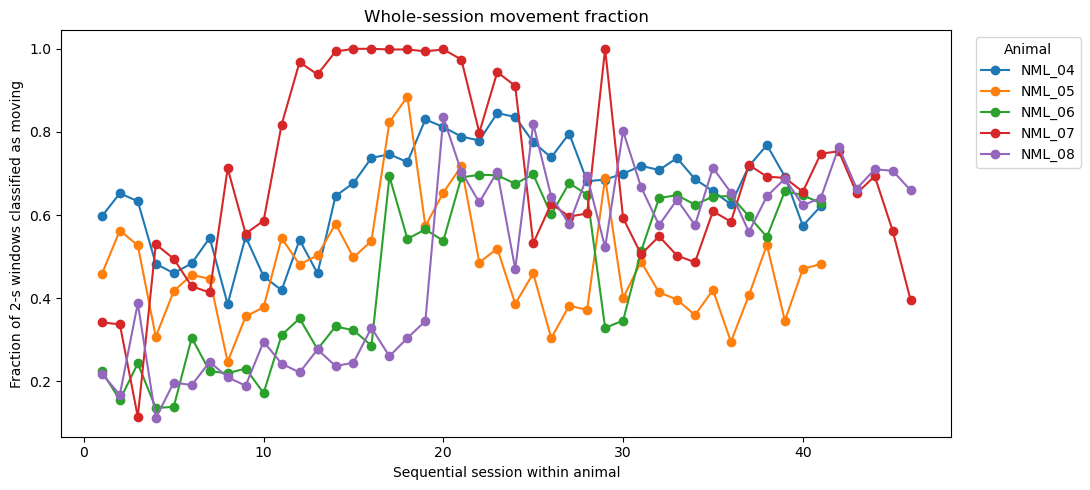

In [17]:
plot_longitudinal_session_feature(
    whole_session_df,
    feature="fraction_moving_2s_windows",
    ylabel="Fraction of 2-s windows classified as moving",
    title="Whole-session movement fraction",
)

plt.show()


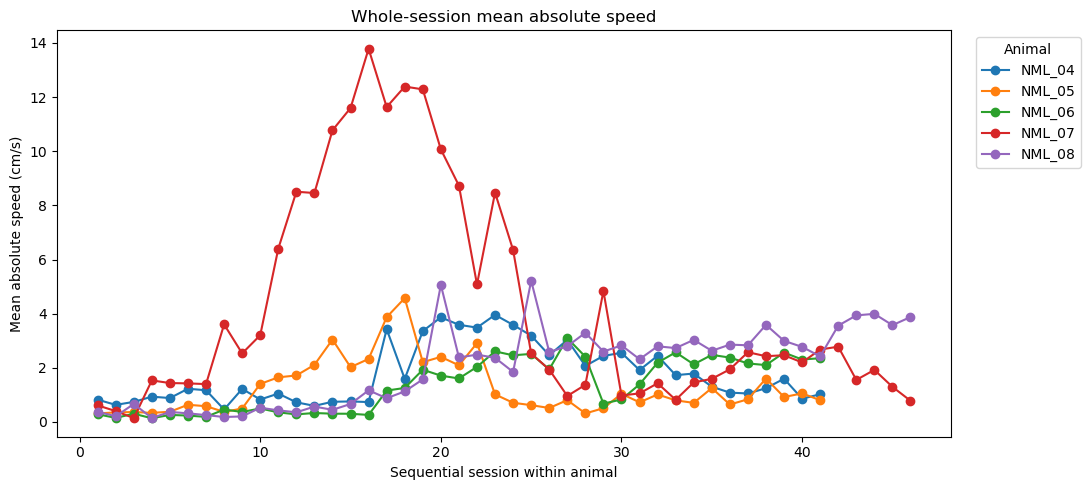

In [18]:
plot_longitudinal_session_feature(
    whole_session_df,
    feature="mean_abs_speed_cms",
    ylabel="Mean absolute speed (cm/s)",
    title="Whole-session mean absolute speed",
)

plt.show()


### Primary whole-session spectral outcomes

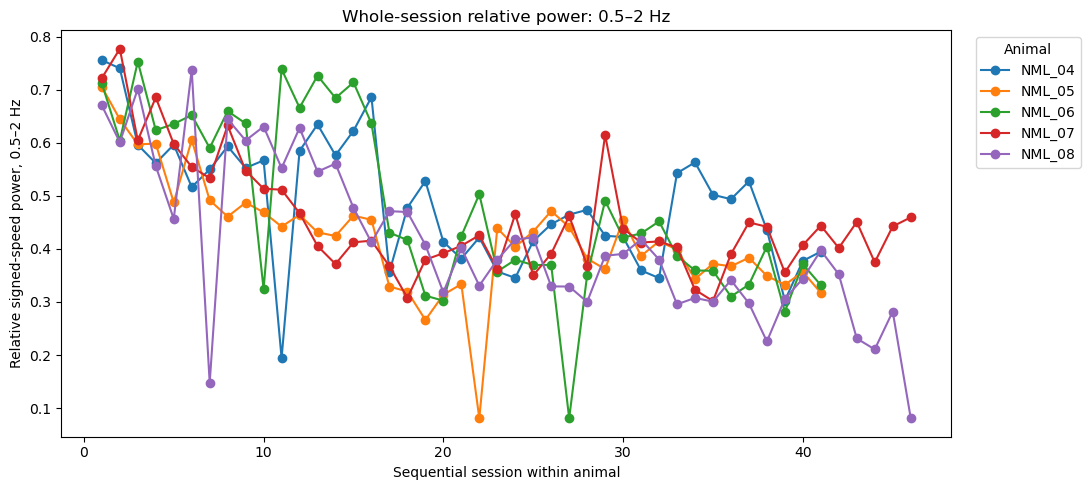

In [19]:
plot_longitudinal_session_feature(
    whole_session_df,
    feature="signed_relative_power_slow_0p5_2",
    ylabel="Relative signed-speed power, 0.5–2 Hz",
    title="Whole-session relative power: 0.5–2 Hz",
)

plt.show()


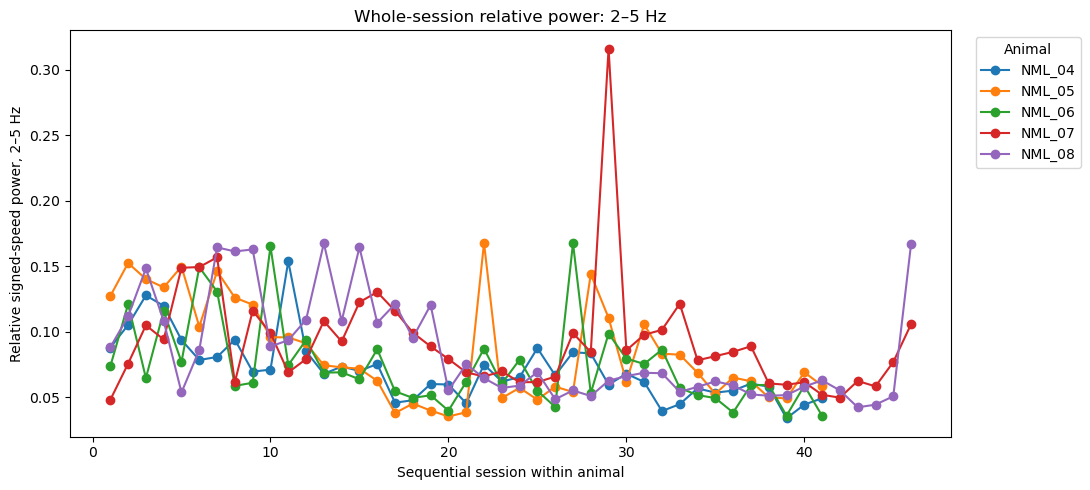

In [20]:
plot_longitudinal_session_feature(
    whole_session_df,
    feature="signed_relative_power_intermediate_2_5",
    ylabel="Relative signed-speed power, 2–5 Hz",
    title="Whole-session relative power: 2–5 Hz",
)

plt.show()


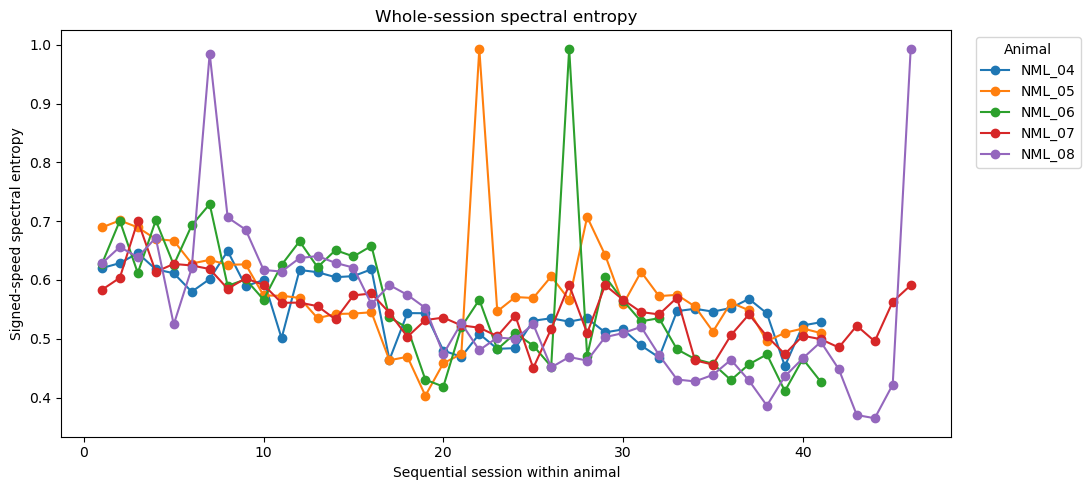

In [21]:
plot_longitudinal_session_feature(
    whole_session_df,
    feature="signed_spectral_entropy",
    ylabel="Signed-speed spectral entropy",
    title="Whole-session spectral entropy",
)

plt.show()


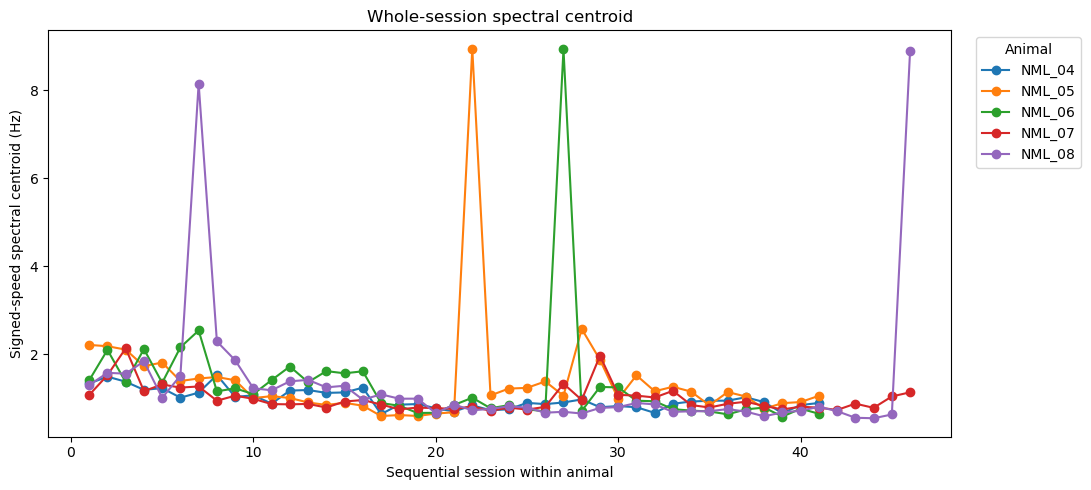

In [22]:
plot_longitudinal_session_feature(
    whole_session_df,
    feature="signed_spectral_centroid_hz",
    ylabel="Signed-speed spectral centroid (Hz)",
    title="Whole-session spectral centroid",
)

plt.show()


## 12. Complete PSD curves by phase

These are descriptive medians across animal-session PSDs at each frequency.


In [23]:
def plot_phase_psd(
    psd_df,
    signal="signed_speed",
    relative=False,
):
    value_column = (
        "relative_power_density"
        if relative
        else "power"
    )

    plot_df = psd_df[
        psd_df["signal"] == signal
    ].copy()

    phase_psd = (
        plot_df
        .groupby(
            ["phase", "frequency_hz"],
            as_index=False,
        )[value_column]
        .median()
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for phase, phase_df in phase_psd.groupby("phase"):
        if relative:
            ax.plot(
                phase_df["frequency_hz"],
                phase_df[value_column],
                label=phase,
            )
        else:
            ax.semilogy(
                phase_df["frequency_hz"],
                phase_df[value_column],
                label=phase,
            )

    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel(
        "Median relative power density"
        if relative
        else "Median session PSD [(cm/s)²/Hz]"
    )
    ax.set_title(f"Whole-session PSD by phase: {signal}")
    ax.legend()
    fig.tight_layout()

    return fig, ax


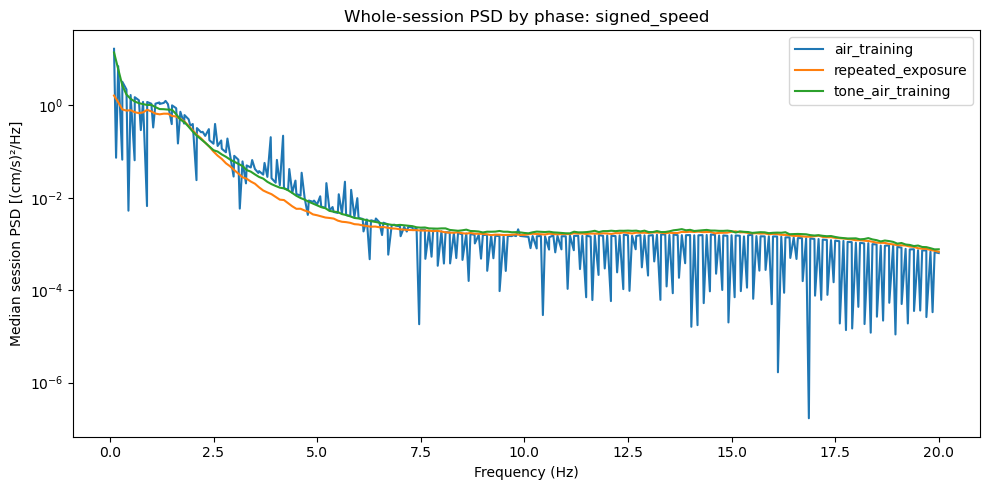

In [24]:
plot_phase_psd(
    whole_session_psd_df,
    signal="signed_speed",
    relative=False,
)

plt.show()


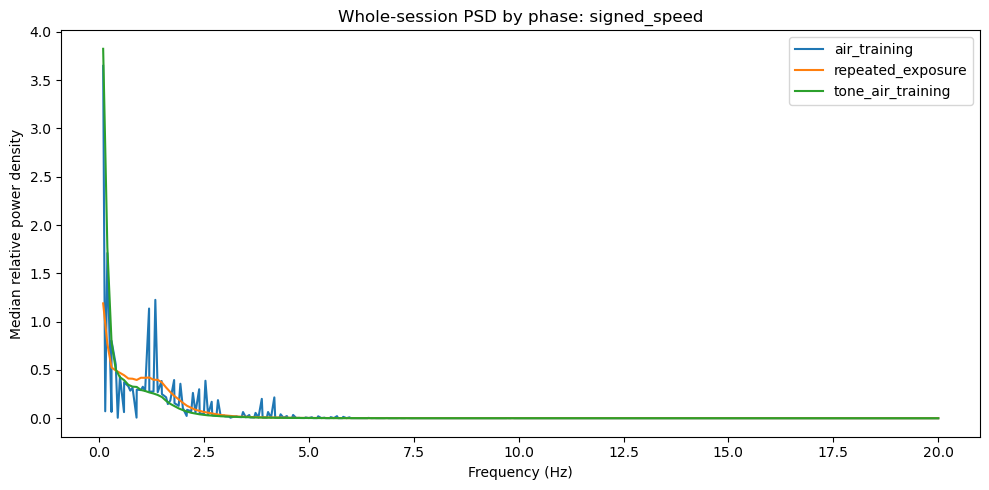

In [25]:
plot_phase_psd(
    whole_session_psd_df,
    signal="signed_speed",
    relative=True,
)

plt.show()


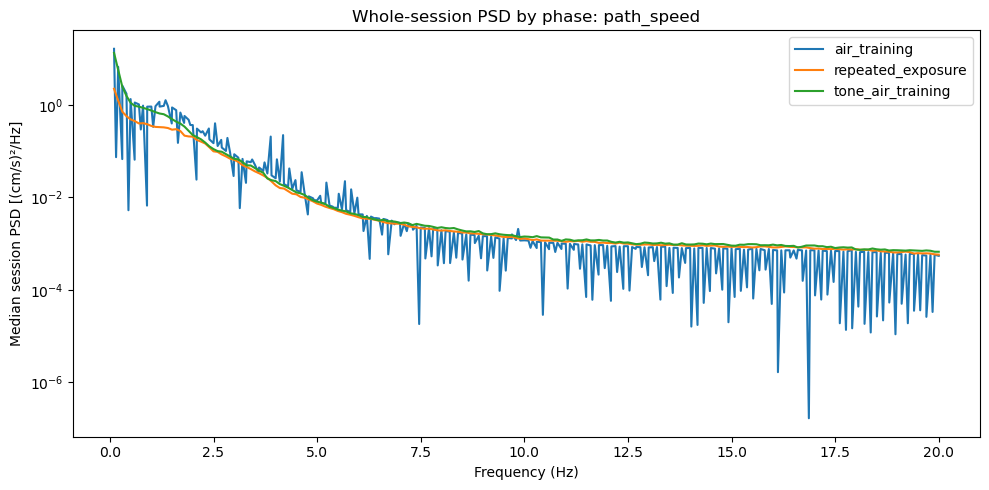

In [26]:
plot_phase_psd(
    whole_session_psd_df,
    signal="path_speed",
    relative=False,
)

plt.show()


## 13. Correlations with conventional behavior

Total power is expected to track movement amount. Relative power, centroid, entropy, dominant frequency, and slope are the more important candidates for information beyond amplitude.


In [27]:
correlation_columns = [
    "mean_abs_speed_cms",
    "fraction_moving_2s_windows",
    "path_distance_from_native_speed_cm",

    "signed_total_power_0p1_20",
    "signed_relative_power_slow_0p5_2",
    "signed_relative_power_intermediate_2_5",
    "signed_dominant_frequency_hz",
    "signed_spectral_centroid_hz",
    "signed_spectral_entropy",

    "path_relative_power_slow_0p5_2",
    "path_relative_power_intermediate_2_5",
    "path_spectral_centroid_hz",
    "path_spectral_entropy",
]

available_correlation_columns = [
    column
    for column in correlation_columns
    if column in whole_session_df.columns
]

session_correlations = (
    whole_session_df[
        available_correlation_columns
    ]
    .corr()
)

display(session_correlations.round(3))


,mean_abs_speed_cms,fraction_moving_2s_windows,path_distance_from_native_speed_cm,signed_total_power_0p1_20,signed_relative_power_slow_0p5_2,signed_relative_power_intermediate_2_5,signed_dominant_frequency_hz,signed_spectral_centroid_hz,signed_spectral_entropy,path_relative_power_slow_0p5_2,path_relative_power_intermediate_2_5,path_spectral_centroid_hz,path_spectral_entropy
mean_abs_speed_cms,1.000,0.761,0.986,0.025,-0.361,-0.056,-0.176,-0.133,-0.271,-0.025,-0.171,-0.166,-0.218
fraction_moving_2s_windows,0.761,1.000,0.731,-0.020,-0.425,-0.262,-0.264,-0.231,-0.447,-0.043,-0.390,-0.297,-0.423
path_distance_from_native_speed_cm,0.986,0.731,1.000,0.078,-0.375,-0.102,-0.161,-0.115,-0.252,-0.057,-0.187,-0.151,-0.199
signed_total_power_0p1_20,0.025,-0.020,0.078,1.000,-0.206,0.173,0.658,0.518,0.341,-0.212,0.182,0.494,0.325
signed_relative_power_slow_0p5_2,-0.361,-0.425,-0.375,-0.206,1.000,0.233,0.305,-0.115,0.364,0.534,0.506,0.011,0.406
signed_relative_power_intermediate_2_5,-0.056,-0.262,-0.102,0.173,0.233,1.000,0.377,0.525,0.682,0.111,0.829,0.603,0.705
signed_dominant_frequency_hz,-0.176,-0.264,-0.161,0.658,0.305,0.377,1.000,0.519,0.529,-0.250,0.594,0.584,0.540
signed_spectral_centroid_hz,-0.133,-0.231,-0.115,0.518,-0.115,0.525,0.519,1.000,0.835,-0.308,0.566,0.987,0.796
signed_spectral_entropy,-0.271,-0.447,-0.252,0.341,0.364,0.682,0.529,0.835,1.000,0.058,0.769,0.889,0.982
path_relative_power_slow_0p5_2,-0.025,-0.043,-0.057,-0.212,0.534,0.111,-0.250,-0.308,0.058,1.000,-0.004,-0.257,0.108


## 14. Scatterplots against mean speed

In [28]:
def plot_feature_against_speed(
    session_df,
    feature,
    speed_feature="mean_abs_speed_cms",
):
    fig, ax = plt.subplots(figsize=(7, 5))

    for animal, animal_df in session_df.groupby("animal"):
        ax.scatter(
            animal_df[speed_feature],
            animal_df[feature],
            label=animal,
        )

    ax.set_xlabel(speed_feature)
    ax.set_ylabel(feature)
    ax.set_title(f"{feature} versus {speed_feature}")

    ax.legend(
        title="Animal",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    fig.tight_layout()

    return fig, ax


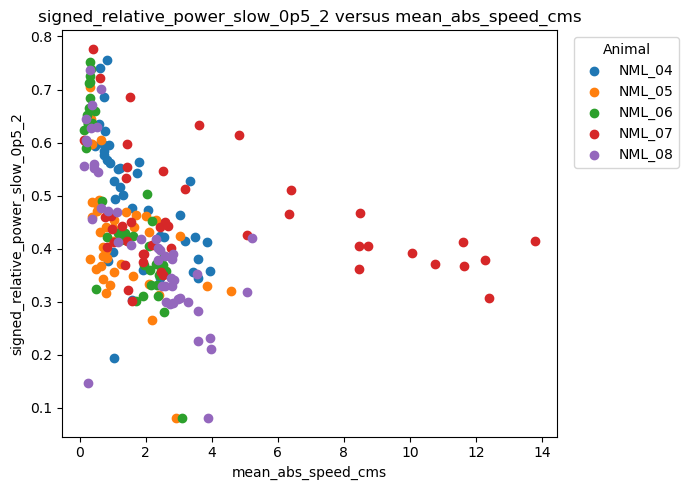

In [29]:
plot_feature_against_speed(
    whole_session_df,
    feature="signed_relative_power_slow_0p5_2",
)

plt.show()


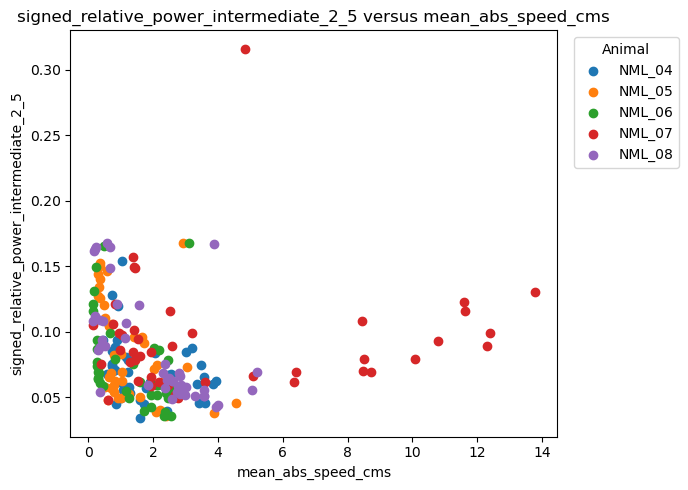

In [30]:
plot_feature_against_speed(
    whole_session_df,
    feature="signed_relative_power_intermediate_2_5",
)

plt.show()


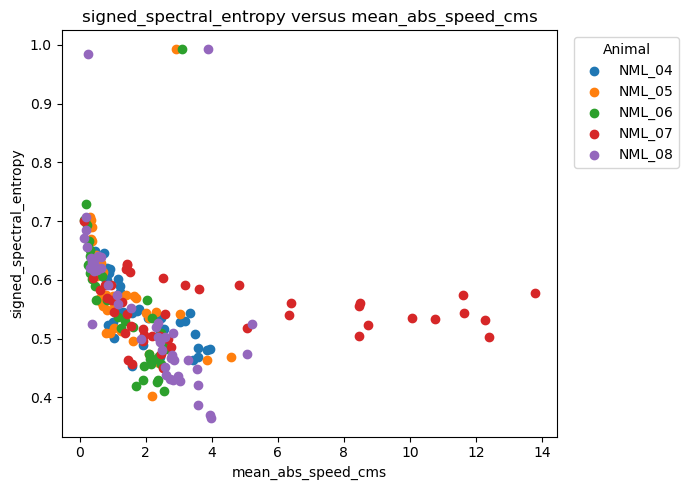

In [31]:
plot_feature_against_speed(
    whole_session_df,
    feature="signed_spectral_entropy",
)

plt.show()


## 15. Optional mixed-effects screening

Each row is an animal-session, with a random intercept for animal.

These are screening models rather than final inferential models. With only five animals, keep the fixed-effect structure parsimonious and inspect every animal trajectory.


In [32]:
import statsmodels.formula.api as smf


def fit_whole_session_mixed_model(
    session_df,
    outcome,
):
    required_columns = [
        outcome,
        "animal",
        "phase",
        "phase_progress_0_1",
        "mean_abs_speed_cms",
        "fraction_moving_2s_windows",
    ]

    model_df = (
        session_df[
            required_columns
        ]
        .dropna()
        .copy()
    )

    if model_df["animal"].nunique() < 2:
        raise ValueError(
            "At least two animals are required for a mixed model."
        )

    model_df["mean_abs_speed_c"] = (
        model_df["mean_abs_speed_cms"]
        - model_df["mean_abs_speed_cms"].mean()
    )

    model_df["fraction_moving_c"] = (
        model_df["fraction_moving_2s_windows"]
        - model_df["fraction_moving_2s_windows"].mean()
    )

    formula = (
        f"{outcome} ~ "
        "C(phase) + "
        "phase_progress_0_1 + "
        "mean_abs_speed_c + "
        "fraction_moving_c"
    )

    model = smf.mixedlm(
        formula=formula,
        data=model_df,
        groups=model_df["animal"],
        re_formula="1",
    )

    result = model.fit(
        reml=True,
        method="lbfgs",
    )

    return result, model_df


In [33]:
candidate_outcomes = [
    "signed_relative_power_slow_0p5_2",
    "signed_relative_power_intermediate_2_5",
    "signed_dominant_frequency_hz",
    "signed_spectral_centroid_hz",
    "signed_spectral_entropy",
]

mixed_model_results = {}

for outcome in candidate_outcomes:
    try:
        result, model_data = fit_whole_session_mixed_model(
            whole_session_df,
            outcome=outcome,
        )

        mixed_model_results[outcome] = result

        print()
        print("=" * 80)
        print(outcome)
        print("=" * 80)
        print(result.summary())

    except Exception as exc:
        print()
        print(
            f"Could not fit {outcome}: "
            f"{type(exc).__name__}: {exc}"
        )


/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the bou


signed_relative_power_slow_0p5_2
                    Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: signed_relative_power_slow_0p5_2
No. Observations: 215     Method:             REML                            
No. Groups:       5       Scale:              0.0069                          
Min. group size:  41      Log-Likelihood:     206.9075                        
Max. group size:  46      Converged:          Yes                             
Mean group size:  43.0                                                        
-------------------------------------------------------------------------------
                                Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------
Intercept                        0.422     0.021  19.911  0.000   0.381   0.464
C(phase)[T.repeated_exposure]    0.176     0.017  10.542  0.000   0.143   0.209
C(phase)[T.tone_air_training]   -0

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th

                  Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: signed_dominant_frequency_hz
No. Observations: 215     Method:             REML                        
No. Groups:       5       Scale:              0.1838                      
Min. group size:  41      Log-Likelihood:     inf                         
Max. group size:  46      Converged:          Yes                         
Mean group size:  43.0                                                    
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        0.000                                    
C(phase)[T.repeated_exposure]    0.183    0.086  2.116 0.034  0.013  0.352
C(phase)[T.tone_air_training]   -0.091    0.078 -1.165 0.244 -0.244  0.062
phase_progress_0_1              -0.283    0.

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: Th

## 16. Interpretation sequence

Review the outputs in this order:

1. **Coverage and quality control**  
   Confirm expected animals and sessions, low immobility noise, and strong agreement between native-derived and stored speed.

2. **Conventional behavior**  
   Inspect movement fraction, mean speed, distance, and longitudinal phase progression.

3. **Absolute spectral power**  
   Determine how strongly total spectral power tracks movement amount.

4. **Relative spectral shape**  
   Focus on 0.5–2 Hz, 2–5 Hz, dominant frequency, centroid, entropy, and slope.

5. **Signed versus path speed**  
   Signed-speed-only effects may reflect directional reversals. Effects present in both may reflect general locomotor modulation.

6. **Animal-level reproducibility**  
   Look for consistent effect directions across animals, not merely session-level significance.

7. **Select outcomes for the next stage**  
   Carry reproducible features forward into:
   - within-session early/middle/late analysis,
   - event-aligned air, LED, and tone analyses,
   - intact locomotor-bout analysis,
   - speed-matched comparisons.

Do not concatenate separated moving samples into one movement-only series, because the artificial joins create spectral transients.


## 17. Reload saved tables without rerunning preprocessing

In [ ]:
# whole_session_df = pd.read_csv(
#     whole_session_output_dir
#     / "whole_session_spectral_features.csv"
# )
#
# whole_session_psd_df = pd.read_csv(
#     whole_session_output_dir
#     / "whole_session_psd_long.csv"
# )
#
# whole_session_errors_df = pd.read_csv(
#     whole_session_output_dir
#     / "whole_session_spectral_errors.csv"
# )
